# Financial Fraud Detection Model with Dashboard
**Zidio final project · Jairus Omondi**

This original notebook follows the supplied project specification and uses **only**
`data/raw/financial_fraud_detection_dataset.csv`. The reference notebook used a different
schema and was not reused for metrics. All results below are recomputed.

Objectives: audit the data, create SQLite ETL, build leakage-safe supervised and unsupervised
pipelines, compare fraud metrics, save reusable models, and connect the same inference code
to the Streamlit dashboard. This is an educational human-review prototype.

Run all cells with Python 3.12 and `requirements.txt` installed. The notebook rebuilds
project artifacts deterministically. It runs from the repository root or its notebook folder.

In [1]:
from pathlib import Path
import json, sys, sqlite3
import numpy as np
import pandas as pd
from IPython.display import display, Image, Markdown

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/train.py').is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.config import RAW_DATA, TARGET
from src.data import load_clean, chronological_split, write_etl
from src.features import TransactionFeatures
from src.predict import PRODUCTION_INPUTS, load_artifacts, score_transactions
from src.evaluation import evaluate
from src.train import run, candidates
print('Project:', ROOT.name)

Project: financial-fraud-detection-dashboard


## 1. Source data and schema
The final CSV is the uploaded `financial_fraud_detection_dataset(2).csv`, renamed without
changing its bytes. Transaction IDs, customer IDs, dates, amounts, merchant/payment/device/location
categories, international status, three history snapshots, a suspicious-keyword flag and the
`Fraudulent` label are present. Currency, source timezone, label-generation process and
external provenance are unspecified.

In [2]:
raw = pd.read_csv(RAW_DATA)
display(raw.head())
display(pd.DataFrame({'dtype': raw.dtypes.astype(str), 'missing': raw.isna().sum(), 'unique': raw.nunique()}))
print('Rows, columns:', raw.shape)

Rows, columns: (5000, 14)


,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Amount,Merchant_Category,Payment_Method,Device_Type,Location,Is_International,Previous_Transactions,Average_Spend,Account_Age_Days,Suspicious_Keyword,Fraudulent
0,T100000,CUST3252,04-10-2023 07:45,37.54,Travel,PayPal,POS,Bengaluru,0,94,417.40,1492,No,0
1,T100001,CUST1630,26-09-2023 08:29,240.81,Utilities,PayPal,Mobile,Bengaluru,0,76,335.47,66,No,0
2,T100002,CUST7852,18-07-2023 15:54,105.34,Entertainment,Debit Card,Mobile,Bengaluru,0,60,432.03,216,No,0
3,T100003,CUST4892,16-10-2023 17:10,73.04,Utilities,NetBanking,Desktop,Kolkata,0,68,488.30,449,No,0
4,T100004,CUST8831,09-09-2023 00:46,13.57,Utilities,Credit Card,Desktop,Bengaluru,0,57,437.03,754,No,0


,dtype,missing,unique
Transaction_ID,object,0,5000
Customer_ID,object,0,3847
Transaction_Date,object,0,4980
Transaction_Amount,float64,0,4302
Merchant_Category,object,0,8
Payment_Method,object,0,5
Device_Type,object,0,3
Location,object,0,7
Is_International,int64,0,2
Previous_Transactions,int64,0,199


## 2. ETL and data-quality audit
Cleaning trims text, parses explicit day-first or ISO dates, validates labels and transaction
keys, removes exact duplicates, and turns invalid optional numerics into missing values.
Median imputation is learned later, inside training pipelines. Zero and extreme amounts
are retained because they can carry a fraud signal. No class resampling occurs during ETL.

In [3]:
clean, audit = load_clean()
display(pd.Series({k: v for k, v in audit.items() if not isinstance(v, (list, dict))}))
display(pd.Series(audit['history_caution']))
db_path = write_etl(clean)
with sqlite3.connect(db_path) as conn:
    sql_summary = pd.read_sql_query('SELECT COUNT(*) AS transactions, SUM(Fraudulent) AS frauds, SUM(Transaction_Amount) AS total_amount FROM transactions', conn)
display(sql_summary)
assert sql_summary.transactions.iloc[0] == len(clean)

source_sha256                             3f106a0947420fee300785f4493847b6bd9efda5647c51...
rows_raw                                                                               5000
exact_duplicates_removed                                                                  0
invalid_key_date_or_label_rows_removed                                                    0
rows_clean                                                                             5000
fraud_count                                                                             482
fraud_rate                                                                           0.0964
total_amount                                                                      395903.32
fraudulent_amount                                                                  39520.96
zero_amount_count                                                                         2
min_date                                                                2023-01-

account_age_decreases                                                            606
previous_transactions_decreases                                                  572
interpretation                     Snapshot definitions and customer-ID consisten...
dtype: object

,transactions,frauds,total_amount
0,5000,482,395903.32


## 3. Leakage checks and fixed split
The dataset contains inconsistent history snapshots within time-sorted customer IDs.
The final feature set excludes `Previous_Transactions`, `Average_Spend` and `Account_Age_Days`.
`Suspicious_Keyword` is also excluded because its availability before fraud adjudication is
unknown. IDs and the target are never model features.

Use the earliest 60% for training, the next 20% for validation and the final 20% for testing.
Identical boundary timestamps stay together. Returning customers can occur across partitions,
but identifiers are not predictors. No scaling, encoding, imputation, balancing or model
selection is fitted on validation/test data. See `docs/evaluation_protocol.md`.

In [4]:
parts = chronological_split(clean)
split_table = pd.DataFrame([{'split': name, 'rows': len(p), 'frauds': int(p.Fraudulent.sum()),
    'fraud_rate': p.Fraudulent.mean(), 'start': p.Transaction_Date.min(), 'end': p.Transaction_Date.max()}
    for name, p in parts.items()])
display(split_table)
assert parts['train'].Transaction_Date.max() < parts['validation'].Transaction_Date.min()
assert parts['validation'].Transaction_Date.max() < parts['test'].Transaction_Date.min()
assert not set(PRODUCTION_INPUTS) & {'Transaction_ID', 'Customer_ID', TARGET, 'Suspicious_Keyword'}

,split,rows,frauds,fraud_rate,start,end
0,train,3000,286,0.095333,2023-01-01 02:16:00,2023-09-11 02:42:00
1,validation,1000,108,0.108000,2023-09-11 05:17:00,2023-11-29 01:11:00
2,test,1000,88,0.088000,2023-11-29 03:08:00,2024-02-21 15:34:00


## 4. Exploratory data analysis
The following full-dataset summaries are descriptive dashboard statistics, not model evaluation.
Inspect class balance, amounts and category rates alongside denominators. Any modelling
interpretation and permutation importance use training or validation data only.

In [5]:
display(clean.groupby(TARGET).agg(transactions=('Transaction_ID', 'size'), amount=('Transaction_Amount', 'sum')))
display(clean[['Transaction_Amount', 'Is_International']].describe())
for column in ['Merchant_Category', 'Location', 'Device_Type', 'Payment_Method']:
    table = clean.groupby(column).agg(transactions=(TARGET, 'size'), frauds=(TARGET, 'sum'))
    table['fraud_rate'] = table.frauds / table.transactions
    display(table.sort_values('fraud_rate', ascending=False))

,transactions,amount
Fraudulent,,
0,4518,356382.36
1,482,39520.96


,Transaction_Amount,Is_International
count,5000.000000,5000.000000
mean,79.180664,0.088200
std,78.964045,0.283614
min,0.000000,0.000000
25%,22.365000,0.000000
50%,55.455000,0.000000
75%,110.297500,0.000000
max,653.800000,1.000000


,transactions,frauds,fraud_rate
Merchant_Category,,,
Entertainment,630,72,0.114286
Food,684,74,0.108187
Fashion,608,62,0.101974
Health,606,61,0.100660
Travel,599,56,0.093489
Grocery,629,58,0.092210
Utilities,594,50,0.084175
Electronics,650,49,0.075385


,transactions,frauds,fraud_rate
Location,,,
Chennai,655,69,0.105344
Mumbai,741,78,0.105263
Bengaluru,686,71,0.103499
Kolkata,713,73,0.102384
Hyderabad,725,64,0.088276
Pune,722,62,0.085873
Delhi,758,65,0.085752


,transactions,frauds,fraud_rate
Device_Type,,,
Desktop,1679,172,0.102442
POS,1673,159,0.095039
Mobile,1648,151,0.091626


,transactions,frauds,fraud_rate
Payment_Method,,,
UPI,961,100,0.104058
Debit Card,1008,103,0.102183
Credit Card,972,96,0.098765
PayPal,1022,98,0.095890
NetBanking,1037,85,0.081967


## 5. Feature engineering and preprocessing
The final pipeline uses seven supplied fields. Row-local engineered features are log(1 + amount),
hour sine/cosine, weekday sine/cosine, and a weekend indicator. These require no future rows.
Numeric median imputation and categorical unknown-value imputation are inside the pipeline.
Categoricals use one-hot encoding with unseen-category support. Standard scaling is used
for Logistic Regression and Isolation Forest; tree classifiers do not require it.

History-based ratios and log transforms exist only for a diagnostic experiment.
No PCA is used: this small mixed dataset has directly interpretable features and the required
visualisations do not need a learned projection.

In [6]:
features = TransactionFeatures(include_history=False).fit_transform(parts['train'][PRODUCTION_INPUTS])
display(features.head())
print('Raw production inputs:', PRODUCTION_INPUTS)
print('Engineered numeric/categorical columns before encoding:', features.shape[1])

Raw production inputs: ['Transaction_Date', 'Transaction_Amount', 'Is_International', 'Merchant_Category', 'Payment_Method', 'Device_Type', 'Location']
Engineered numeric/categorical columns before encoding: 12


,Transaction_Amount,Is_International,Merchant_Category,Payment_Method,Device_Type,Location,Hour_Sin,Hour_Cos,Weekday_Sin,Weekday_Cos,Is_Weekend,Log_Amount
0,210.69,0,Grocery,PayPal,Desktop,Hyderabad,0.559193,0.829038,-0.781831,0.62349,1.0,5.355123
1,66.73,1,Entertainment,Debit Card,Desktop,Hyderabad,0.998135,0.061049,-0.781831,0.62349,1.0,4.215529
2,14.24,0,Utilities,Debit Card,POS,Pune,0.688355,-0.725374,-0.781831,0.62349,1.0,2.723924
3,74.90,0,Fashion,Debit Card,Desktop,Hyderabad,0.113203,-0.993572,-0.781831,0.62349,1.0,4.329417
4,45.04,0,Grocery,NetBanking,POS,Chennai,0.082808,-0.996566,-0.781831,0.62349,1.0,3.829511


## 6. Supervised comparison and unsupervised detector
Compare Logistic Regression, a constrained Decision Tree, Random Forest and histogram
gradient boosting, each with and without class weights. Histogram gradient boosting is
the suitable gradient-boosting alternative to XGBoost and avoids an additional dependency.

Select by validation **average precision (AP)**, then set the decision threshold by maximum
validation F1. This is a demo threshold; business costs and review capacity are not supplied.
SMOTE is unnecessary for this benchmark: class weights are compared directly and no synthetic
training rows are introduced.

Isolation Forest is fitted to all unlabelled training features. Its review cutoff is the
90th percentile of training anomaly scores, a fixed 10% review-budget assumption. Fraud
labels are used only to evaluate it. Anomaly scores are not fraud probabilities. One-Class
SVM and neural autoencoders would add cost without an established benefit here.

In [7]:
# This cell actually rebuilds ETL, all models, diagnostics, scores, alerts and figures.
# The model/threshold are frozen on validation before any test model comparison is computed.
results = run(data_path=RAW_DATA, output_root=ROOT)

Audited 5000 rows. Split: 3000/1000/1000.
Validation Logistic Regression (unweighted): AP=0.3947, F1=0.4593
Validation Decision Tree (unweighted): AP=0.3354, F1=0.4434
Validation Random Forest (unweighted): AP=0.3848, F1=0.4494
Validation Histogram Gradient Boosting (unweighted): AP=0.3235, F1=0.4388
Validation Logistic Regression (balanced): AP=0.3841, F1=0.4157
Validation Decision Tree (balanced): AP=0.3332, F1=0.4279
Validation Random Forest (balanced): AP=0.3840, F1=0.4560
Validation Histogram Gradient Boosting (balanced): AP=0.3410, F1=0.4503
FROZEN selection: Logistic Regression (unweighted), threshold=0.15906132
{
  "selected_model": "Logistic Regression (unweighted)",
  "test": {
    "n": 1000,
    "fraud_count": 88,
    "prevalence": 0.088,
    "threshold": 0.15906131809580412,
    "precision": 0.27848101265822783,
    "recall": 0.5,
    "f1": 0.35772357723577236,
    "roc_auc": 0.8018839712918661,
    "average_precision": 0.31566086158259576,
    "pr_auc": 0.3119473378004926,

In [8]:
comparison = pd.read_csv(ROOT / 'outputs/model_comparison.csv')
columns = ['model','precision','recall','f1','roc_auc','average_precision','pr_auc','threshold']
display(comparison.loc[comparison.split.eq('validation'), columns].sort_values('average_precision', ascending=False))
print('Frozen selected model:', results['final_model'])

Frozen selected model: Logistic Regression (unweighted)


,model,precision,recall,f1,roc_auc,average_precision,pr_auc,threshold
0,Logistic Regression (unweighted),0.382716,0.574074,0.459259,0.825766,0.394681,0.390492,0.159061
2,Random Forest (unweighted),0.322581,0.740741,0.449438,0.836800,0.384756,0.380400,0.151208
4,Logistic Regression (balanced),0.360544,0.490741,0.415686,0.820524,0.384085,0.379895,0.667541
6,Random Forest (balanced),0.316547,0.814815,0.455959,0.845395,0.383961,0.376580,0.453295
7,Histogram Gradient Boosting (balanced),0.329060,0.712963,0.450292,0.829752,0.341030,0.334635,0.531309
1,Decision Tree (unweighted),0.299674,0.851852,0.443373,0.833920,0.335388,0.353200,0.145329
5,Decision Tree (balanced),0.288961,0.824074,0.427885,0.822626,0.333246,0.359055,0.613584
3,Histogram Gradient Boosting (unweighted),0.302817,0.796296,0.438776,0.827001,0.323454,0.316330,0.098771
17,Isolation Forest,0.352381,0.342593,0.347418,0.661134,0.230815,0.225062,0.517216
16,Dummy prior / no fraud alerts,0.000000,0.000000,0.000000,0.500000,0.108000,0.554000,0.500000


## 7. Held-out test evaluation
Every model uses the same untouched test period. Test results describe the already-frozen
selection; they are not used to switch models. Precision, recall and F1 use the saved
validation threshold. ROC-AUC and PR summaries use continuous scores.

AP is the primary PR summary; trapezoidal PR-AUC is reported separately. The dummy model's
trapezoidal PR-AUC can appear large because it interpolates between just a few endpoints.
Its AP equals prevalence and correctly indicates no useful ranking.

,model,precision,recall,f1,roc_auc,average_precision,pr_auc,threshold
8,Logistic Regression (unweighted),0.278481,0.500000,0.357724,0.801884,0.315661,0.311947,0.159061
14,Random Forest (balanced),0.251938,0.738636,0.375723,0.823926,0.314963,0.310157,0.453295
10,Random Forest (unweighted),0.256410,0.681818,0.372671,0.824773,0.312579,0.306772,0.151208
12,Logistic Regression (balanced),0.301471,0.465909,0.366071,0.797199,0.309389,0.305587,0.667541
15,Histogram Gradient Boosting (balanced),0.232456,0.602273,0.335443,0.803790,0.281601,0.277116,0.531309
9,Decision Tree (unweighted),0.247423,0.818182,0.379947,0.822169,0.279716,0.305767,0.145329
13,Decision Tree (balanced),0.251678,0.852273,0.388601,0.824561,0.277838,0.305614,0.613584
11,Histogram Gradient Boosting (unweighted),0.235714,0.750000,0.358696,0.814755,0.265469,0.259257,0.098771
19,Isolation Forest,0.295918,0.329545,0.311828,0.660013,0.220257,0.216017,0.517216
18,Dummy prior / no fraud alerts,0.000000,0.000000,0.000000,0.500000,0.088000,0.544000,0.500000


n                    1000.000000
fraud_count            88.000000
prevalence              0.088000
threshold               0.159061
precision               0.278481
recall                  0.500000
f1                      0.357724
roc_auc                 0.801884
average_precision       0.315661
pr_auc                  0.311947
tn                    798.000000
fp                    114.000000
fn                     44.000000
tp                     44.000000
alert_count           158.000000
alert_rate              0.158000
dtype: float64

,Predicted legitimate,Predicted review
Actual legitimate,798,114
Actual fraud,44,44


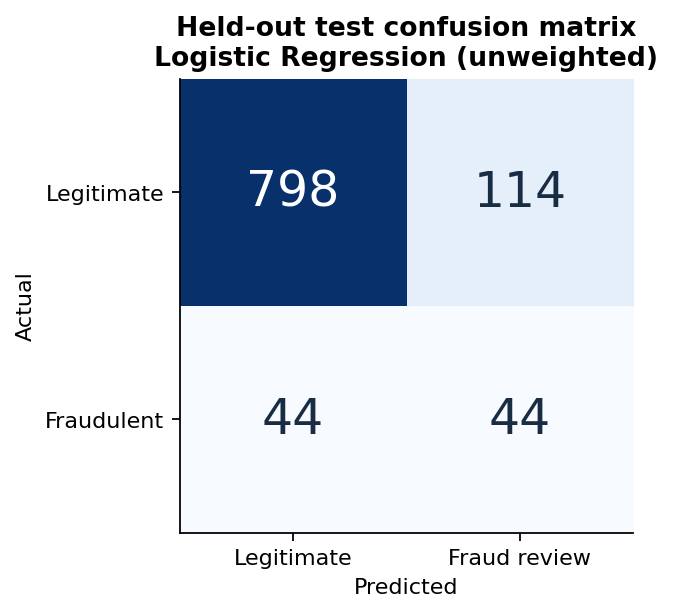

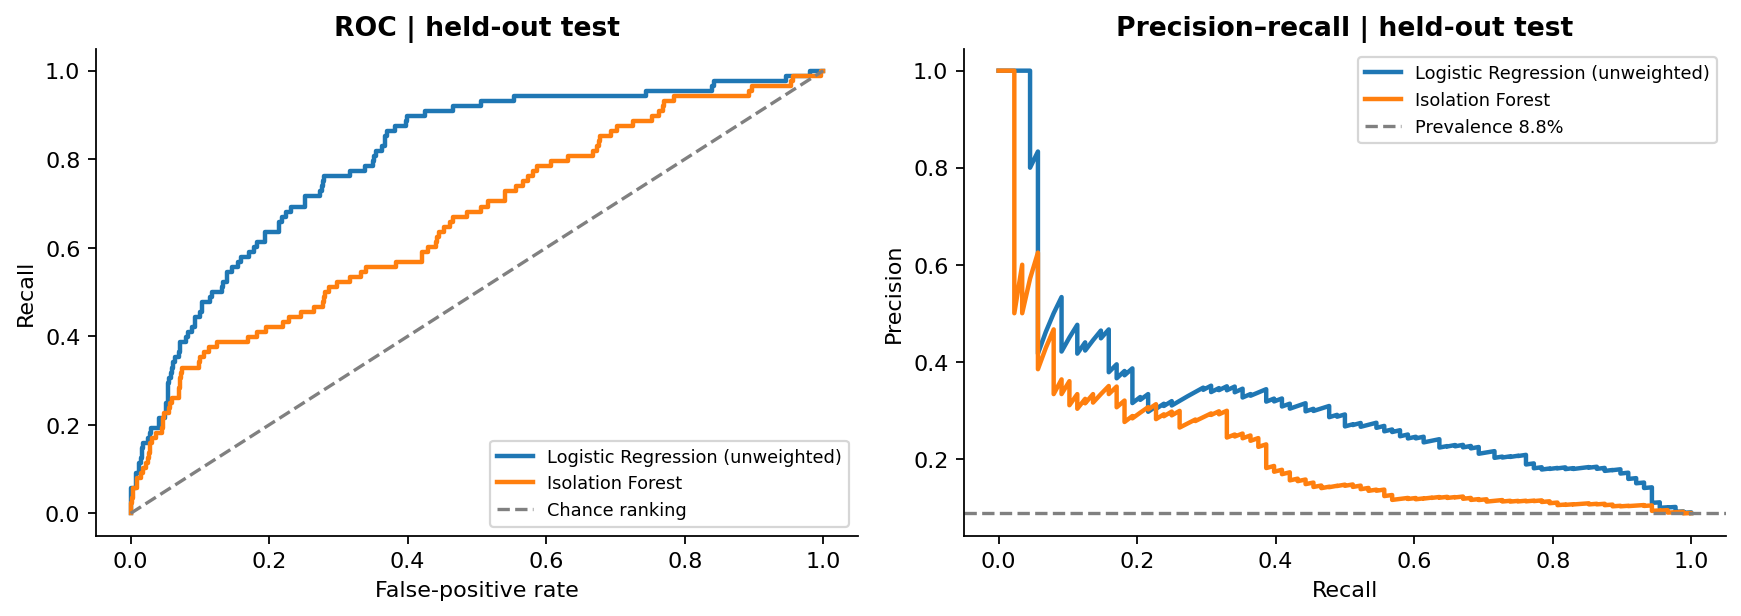

In [9]:
display(comparison.loc[comparison.split.eq('test'), columns].sort_values('average_precision', ascending=False))
display(pd.Series(results['test']))
m = results['test']
display(pd.DataFrame([[m['tn'],m['fp']],[m['fn'],m['tp']]], index=['Actual legitimate','Actual fraud'], columns=['Predicted legitimate','Predicted review']))
display(Image(filename=str(ROOT / 'outputs/figures/confusion_matrix.png')))
display(Image(filename=str(ROOT / 'outputs/figures/test_curves.png')))

## 8. Uncertainty, customer overlap and source sensitivity
The customer-group bootstrap resamples test customers with replacement, keeping each
customer's rows together. Its intervals are conditional on the fitted model and this
sample; they do not capture training/selection uncertainty or institutional transfer.
Seen/unseen customer slices help disclose the implications of the chronological split.
The two feature sensitivity experiments use validation only and cannot replace the final model.

,2.5th percentile,97.5th percentile
precision,0.204950,0.349506
recall,0.396015,0.591402
f1,0.275062,0.430038
roc_auc,0.751980,0.846563
average_precision,0.231112,0.405261
pr_auc,0.224295,0.399993


,customer_slice,n,fraud_count,prevalence,threshold,precision,recall,f1,roc_auc,average_precision,pr_auc,tn,fp,fn,tp,alert_count,alert_rate
0,seen in training,257,12,0.046693,0.159061,0.214286,0.750000,0.333333,0.871429,0.352135,0.330763,212,33,3,9,42,0.163424
1,unseen in training,743,76,0.102288,0.159061,0.301724,0.460526,0.364583,0.789454,0.326960,0.322707,586,81,41,35,116,0.156124


,variant,validation_ap
0,Final: transaction-time fields only,0.394681
1,Add unverified history (diagnostic only),0.374358
2,Add suspicious keyword (diagnostic only),0.469561


,feature,validation_ap_drop_mean,validation_ap_drop_std
0,Is_International,0.189128,0.014008
1,Transaction_Date,0.168014,0.021046
2,Merchant_Category,0.007890,0.004153
3,Payment_Method,0.003055,0.004727
4,Device_Type,-0.000432,0.002102
5,Transaction_Amount,-0.004681,0.003980
6,Location,-0.005917,0.004479


model                Isolation Forest
split                            test
kind                     unsupervised
n                                1000
fraud_count                        88
prevalence                      0.088
threshold                    0.517216
precision                    0.295918
recall                       0.329545
f1                           0.311828
roc_auc                      0.660013
average_precision            0.220257
pr_auc                       0.216017
tn                                843
fp                                 69
fn                                 59
tp                                 29
alert_count                        98
alert_rate                      0.098
dtype: object

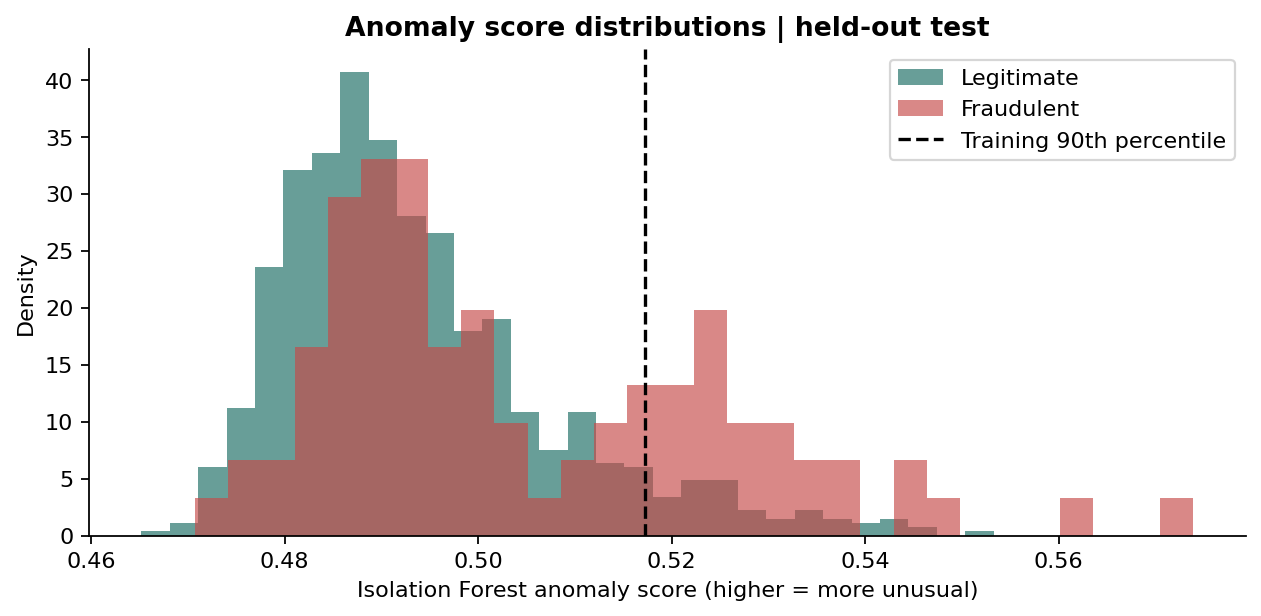

In [10]:
display(pd.DataFrame(results['test_confidence_intervals']['intervals_95'], index=['2.5th percentile','97.5th percentile']).T)
display(pd.DataFrame(results['customer_slices']))
display(pd.read_csv(ROOT / 'outputs/feature_sensitivity.csv'))
display(pd.read_csv(ROOT / 'outputs/feature_importance.csv'))
display(pd.Series(results['isolation_forest_test']))
display(Image(filename=str(ROOT / 'outputs/figures/anomaly_scores.png')))

## 9. Saved models and scored outputs
The saved joblib bundles contain the entire fitted feature/preprocessing/model pipeline and
the frozen threshold. Load only trusted model files. The dashboard calls the same
`score_transactions` function below. Labels and IDs, even when supplied, cannot affect scores.
The exact train-only fitted model used for test evaluation is retained, without a silent refit.

In [11]:
model_bundle, anomaly_bundle = load_artifacts()
scored = score_transactions(parts['test'], model_bundle, anomaly_bundle)
saved = pd.read_csv(ROOT / 'outputs/test_predictions.csv')
np.testing.assert_allclose(scored.Fraud_Score, saved.Fraud_Score, atol=1e-12)
recomputed = evaluate(scored.Fraudulent, scored.Fraud_Score, model_bundle['threshold'])
assert np.isclose(recomputed['f1'], results['test']['f1'])
display(scored[['Transaction_ID','Fraudulent','Fraud_Score','Predicted_Fraud','Anomaly_Score','Anomaly_Flag']].head(10))
print('Saved-pipeline predictions and reported metrics match.')

Saved-pipeline predictions and reported metrics match.


,Transaction_ID,Fraudulent,Fraud_Score,Predicted_Fraud,Anomaly_Score,Anomaly_Flag
0,T100287,0,0.147909,0,0.485472,0
1,T100477,0,0.133163,0,0.487278,0
2,T104870,0,0.096617,0,0.484705,0
3,T100288,0,0.055832,0,0.474744,0
4,T100450,0,0.018000,0,0.493666,0
5,T102715,0,0.015905,0,0.473386,0
6,T102141,0,0.015790,0,0.472752,0
7,T103407,0,0.033381,0,0.514757,0
8,T100598,0,0.045725,0,0.486925,0
9,T101330,0,0.113295,0,0.471035,0


In [12]:
from src.alerts import simulate_alerts
alerts = simulate_alerts(scored, limit=3)
display(pd.DataFrame(alerts))
print('Simulation only. No credentials or external notifications are used.')

Simulation only. No credentials or external notifications are used.


,status,action,transaction_id,transaction_date,amount,fraud_score,anomaly_flag,message
0,SIMULATED_ONLY,human_review_requested,T103641,2024-01-24 03:03:00,191.26,0.808169,1,Score exceeded the frozen validation threshold...
1,SIMULATED_ONLY,human_review_requested,T102836,2024-01-07 01:31:00,399.92,0.794021,1,Score exceeded the frozen validation threshold...
2,SIMULATED_ONLY,human_review_requested,T101954,2023-12-18 03:30:00,512.44,0.743328,1,Score exceeded the frozen validation threshold...


## 10. Dashboard and reproducibility
Launch from the repository root:
```bash
python -m streamlit run app.py
```
Six pages cover Executive Overview, Fraud Analysis, Transaction Patterns, Risk/Anomaly
Analysis, Model Performance, and Transaction Prediction. Filters update descriptive
transaction views. Performance remains fixed to the test period. The UI supports a
single-transaction form, batch CSV scoring, anomaly plots and a simulated review queue.

Use `python -m pytest` for the pipeline/dashboard checks. Use `python scripts/verify_fresh_run.py`
to rebuild models in an empty temporary output directory, compare results, and check
serialized prediction consistency. Read `README.md` for exact installation commands.

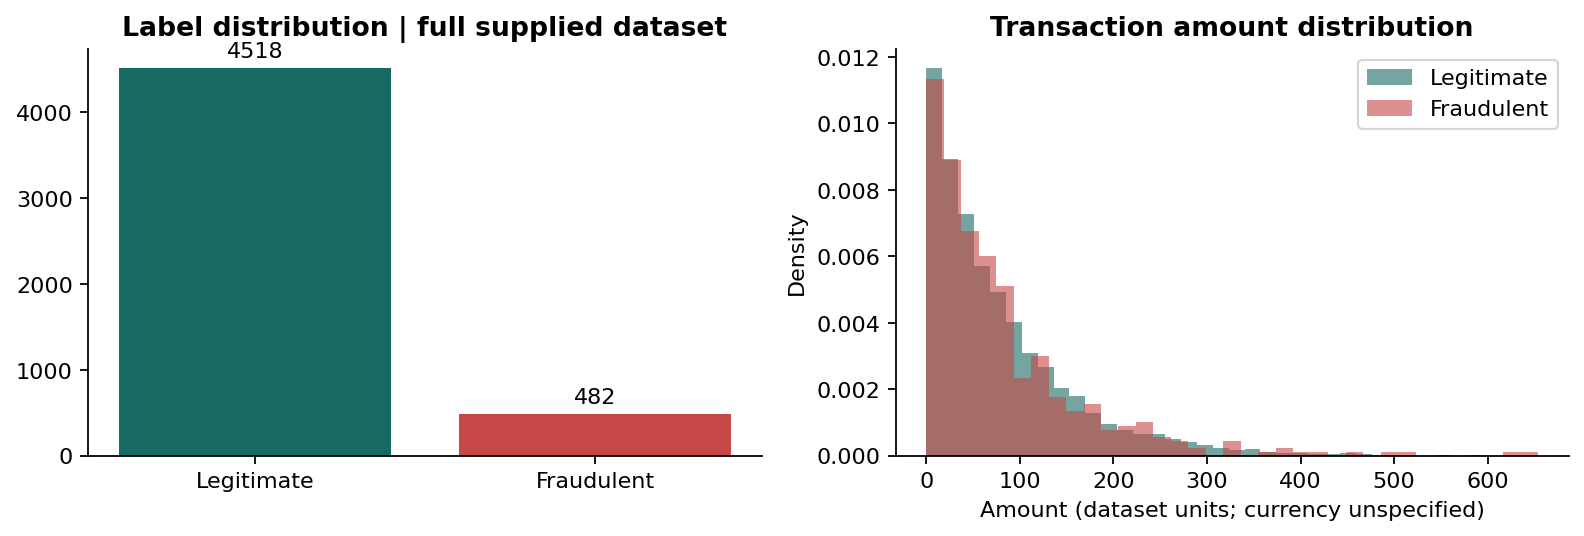

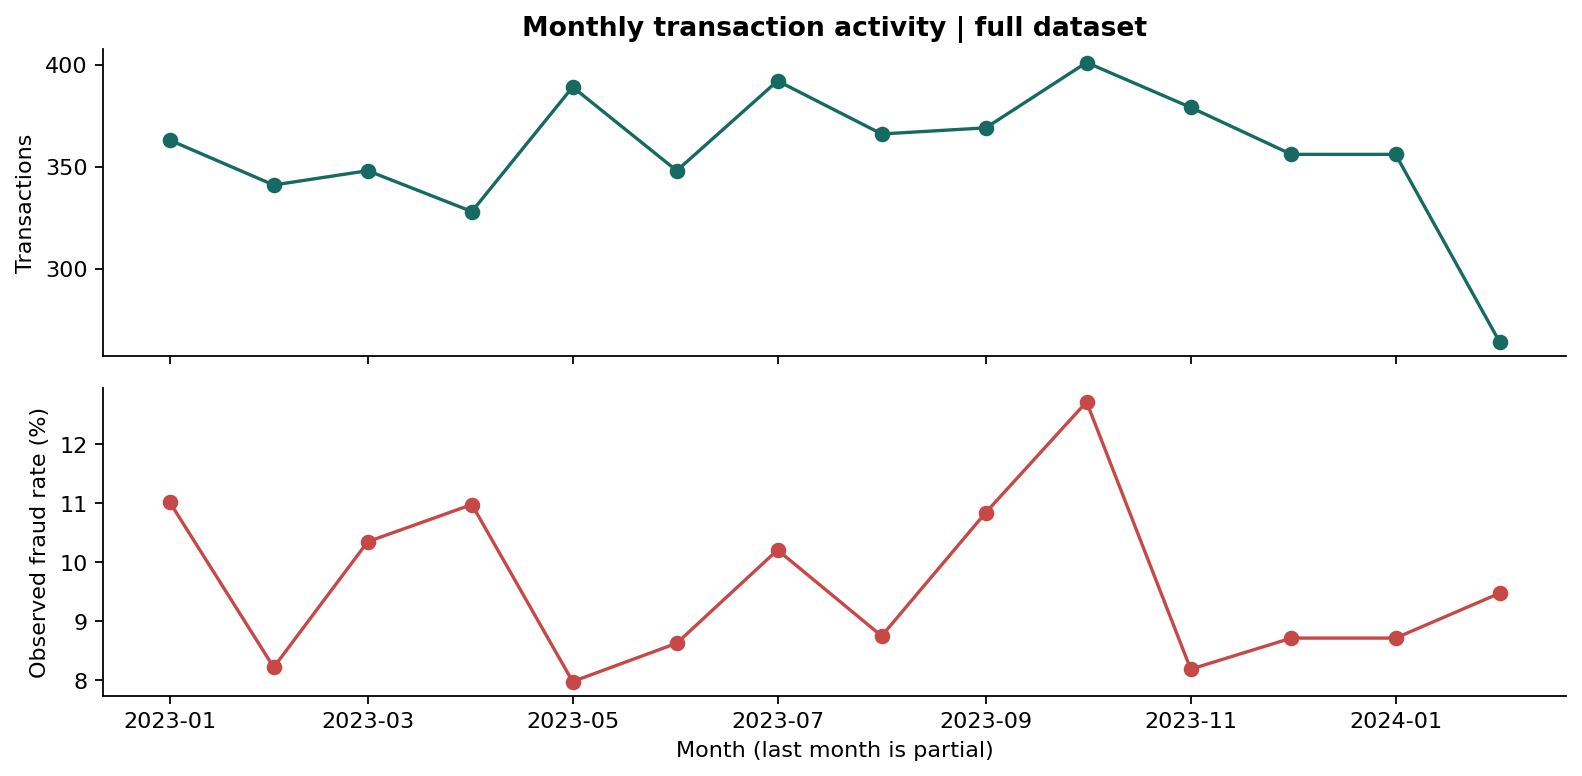

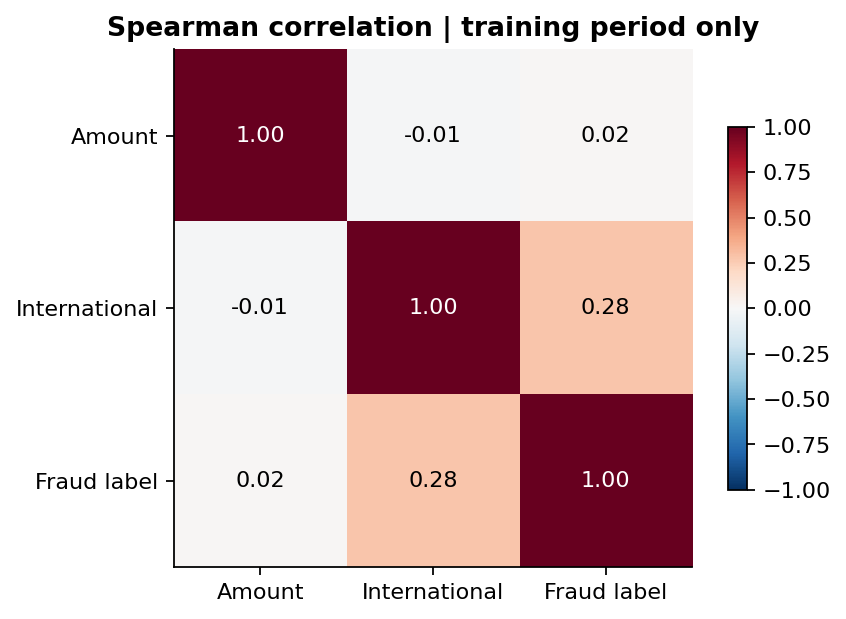

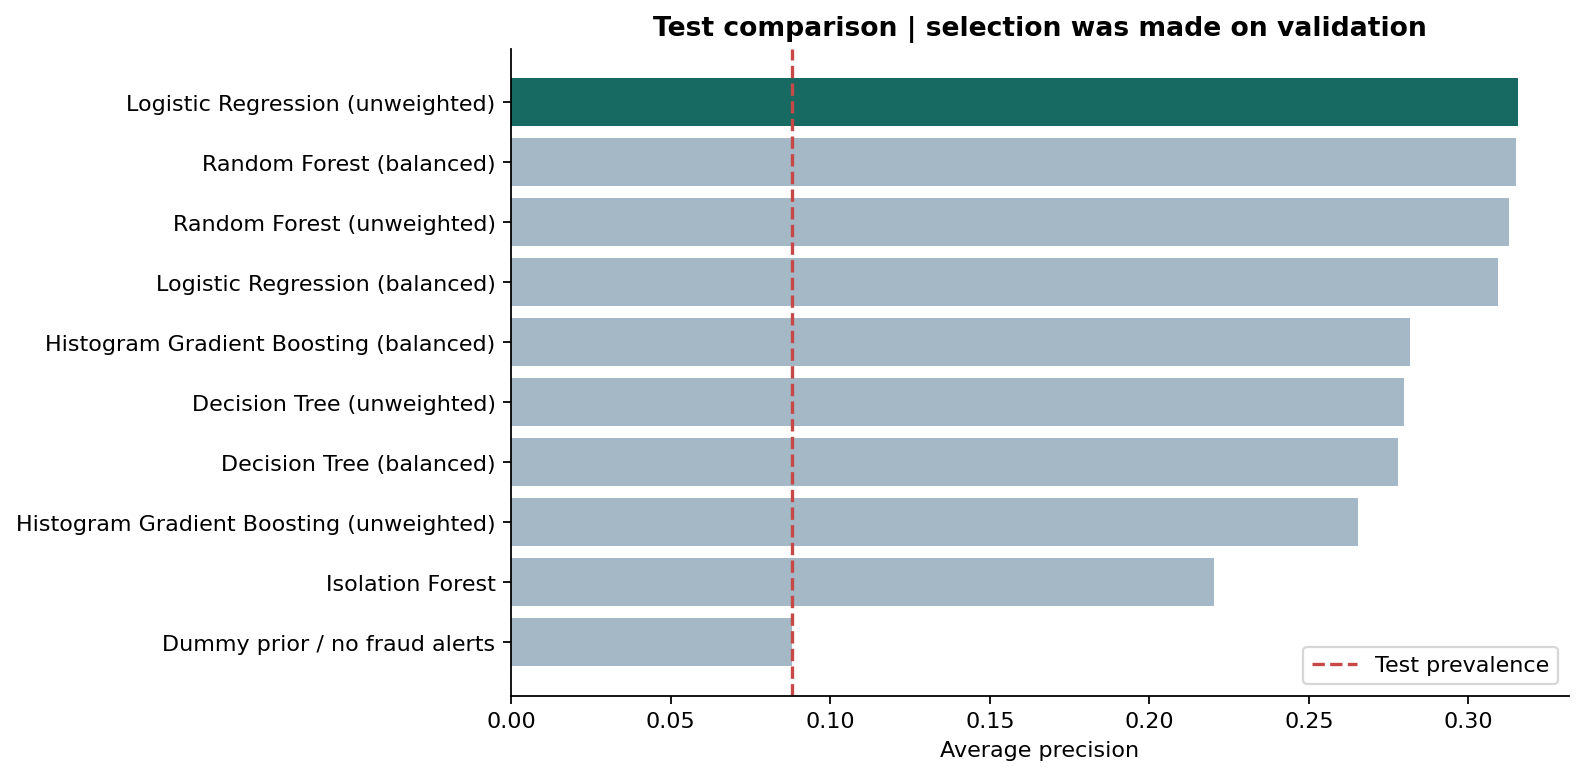

In [13]:
for figure in ['dataset_overview.png', 'monthly_trends.png', 'training_correlation.png', 'model_comparison.png']:
    display(Image(filename=str(ROOT / 'outputs/figures' / figure)))

## 11. Conclusions and limitations
The selected model provides useful ranking relative to test prevalence, but precision and
recall remain limited. A review flag is not proof of fraud, and a lower score is not proof
of legitimacy. Scores have not been calibrated. This supplied dataset has only 88 test
frauds, inconsistent histories, and unspecified provenance/currency/timezone; findings
cannot be represented as validated live-bank performance.

Priority improvements are verified point-in-time transaction histories, label/source
documentation, external and rolling-period validation, review-cost thresholding and
calibration. Kafka/Spark ingestion, graph analysis, email notification, adaptive learning,
mobile integration, credit scoring and blockchain are explicitly future work. The current
project provides offline ETL, batch scoring and a simulated alert workflow.

References: [scikit-learn leakage guidance](https://scikit-learn.org/stable/common_pitfalls.html),
[average precision definition](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html),
[Streamlit AppTest](https://docs.streamlit.io/develop/api-reference/app-testing/st.testing.v1.apptest).